# Controllability Summary Analysis

In [1]:

from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_UTILS_DIR = Path("benchmark/runtime/notebooks").resolve()
if not NOTEBOOK_UTILS_DIR.exists():
    NOTEBOOK_UTILS_DIR = Path.cwd().resolve().parent
if str(NOTEBOOK_UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_UTILS_DIR))

from notebook_utils import (
    SECONDARY_LANES,
    SECONDARY_MODELS,
    SECONDARY_STUDIES,
    annotate_secondary_reportability,
    find_runtime_root,
    load_secondary_coverage,
    load_secondary_flat,
    plot_secondary_delta_ci,
    plot_secondary_model_heatmap,
    secondary_lane_summary,
    secondary_missing_table,
    secondary_threshold_audit,
    setup_notebook_style,
)

setup_notebook_style()
runtime_root = Path("benchmark/runtime").resolve()
if not (runtime_root / "metric-results").exists():
    runtime_root = find_runtime_root()
metric_root = runtime_root / "metric-results" / "secondary_branch_metrics"
flat = load_secondary_flat(metric_root)
coverage = load_secondary_coverage(metric_root)
flat = annotate_secondary_reportability(flat)
metric_root


PosixPath('/Users/ryangichuru/Documents/SSD-K/Uni/3rd year/NLP-ready/benchmark/runtime/metric-results/secondary_branch_metrics')

## Provenance and NLI settings
Study B and Study C secondary metrics are run with NLI enabled (`use_nli=True`, `nli_stride=1`). The NLI utility auto-selects MPS when available.

In [2]:

print("Secondary metric root:", metric_root)
print("Rows:", len(flat), "Coverage cells:", len(coverage))
print("NLI flags:")
display(coverage.groupby(["lane", "use_nli", "nli_stride"], dropna=False).size().reset_index(name="jobs"))
print("Data roots:")
display(coverage[coverage["status"] == "ok"].groupby(["lane", "data_root"], dropna=False).size().reset_index(name="jobs"))


Secondary metric root: /Users/ryangichuru/Documents/SSD-K/Uni/3rd year/NLP-ready/benchmark/runtime/metric-results/secondary_branch_metrics
Rows: 268 Coverage cells: 90
NLI flags:


,lane,use_nli,nli_stride,jobs
0,controllability,NaN,NaN,6
1,controllability,True,1.0,24
2,ctrl-invariance,NaN,NaN,9
3,ctrl-invariance,True,1.0,21
4,invariance,NaN,NaN,7
5,invariance,True,1.0,23


Data roots:


,lane,data_root,jobs
0,controllability,/private/tmp/nlp-ready-controllability/benchma...,24
1,ctrl-invariance,/private/tmp/nlp-ready-metric-invariance/bench...,21
2,invariance,/private/tmp/nlp-ready-metric-invariance/bench...,23


## Lane-level model summary

In [3]:

display(secondary_lane_summary(flat).round(4))
missing = secondary_missing_table(coverage)
display(missing[["lane", "model", "study", "status"]])


,lane,model,metric_rows,studies,metrics,median_delta,max_abs_delta,median_n_pairs
4,controllability,qwen3-lmstudio,30,5,15,0.0000,1.3000,1.0
0,controllability,gpt-oss-20b,30,5,15,0.0000,0.7250,1.0
1,controllability,piaget-8b-local,30,5,15,0.0000,0.2676,1.0
2,controllability,psyche-r1-local,18,3,9,0.0000,0.1667,0.0
3,controllability,psyllm-lmstudio,30,5,15,0.0000,0.0333,0.0
8,ctrl-invariance,psyllm-lmstudio,15,5,15,0.0000,1.0000,10.0
5,ctrl-invariance,gpt-oss-20b,15,5,15,0.0000,0.0000,0.0
6,ctrl-invariance,piaget-8b-local,15,5,15,0.0000,0.0000,0.0
7,ctrl-invariance,psyche-r1-local,1,1,1,0.0000,0.0000,0.0
9,ctrl-invariance,qwen3-lmstudio,15,5,15,0.0000,0.0000,0.0


,lane,model,study,status
0,controllability,deepseek-r1-lmstudio,study_a,missing_cache
1,controllability,deepseek-r1-lmstudio,study_b,missing_cache
2,controllability,deepseek-r1-lmstudio,study_b_multi_turn,missing_cache
3,controllability,deepseek-r1-lmstudio,study_c,missing_cache
4,controllability,psyche-r1-local,study_b_multi_turn,missing_cache
5,controllability,psyche-r1-local,study_c,missing_cache
6,ctrl-invariance,deepseek-r1-lmstudio,study_a,missing_cache
7,ctrl-invariance,deepseek-r1-lmstudio,study_a_bias,missing_cache
8,ctrl-invariance,deepseek-r1-lmstudio,study_b,missing_cache
9,ctrl-invariance,deepseek-r1-lmstudio,study_b_multi_turn,missing_cache


## Delta views
Heatmaps show median paired deltas by model and study. Errorbar plots show the largest absolute paired shifts with 95% CIs.

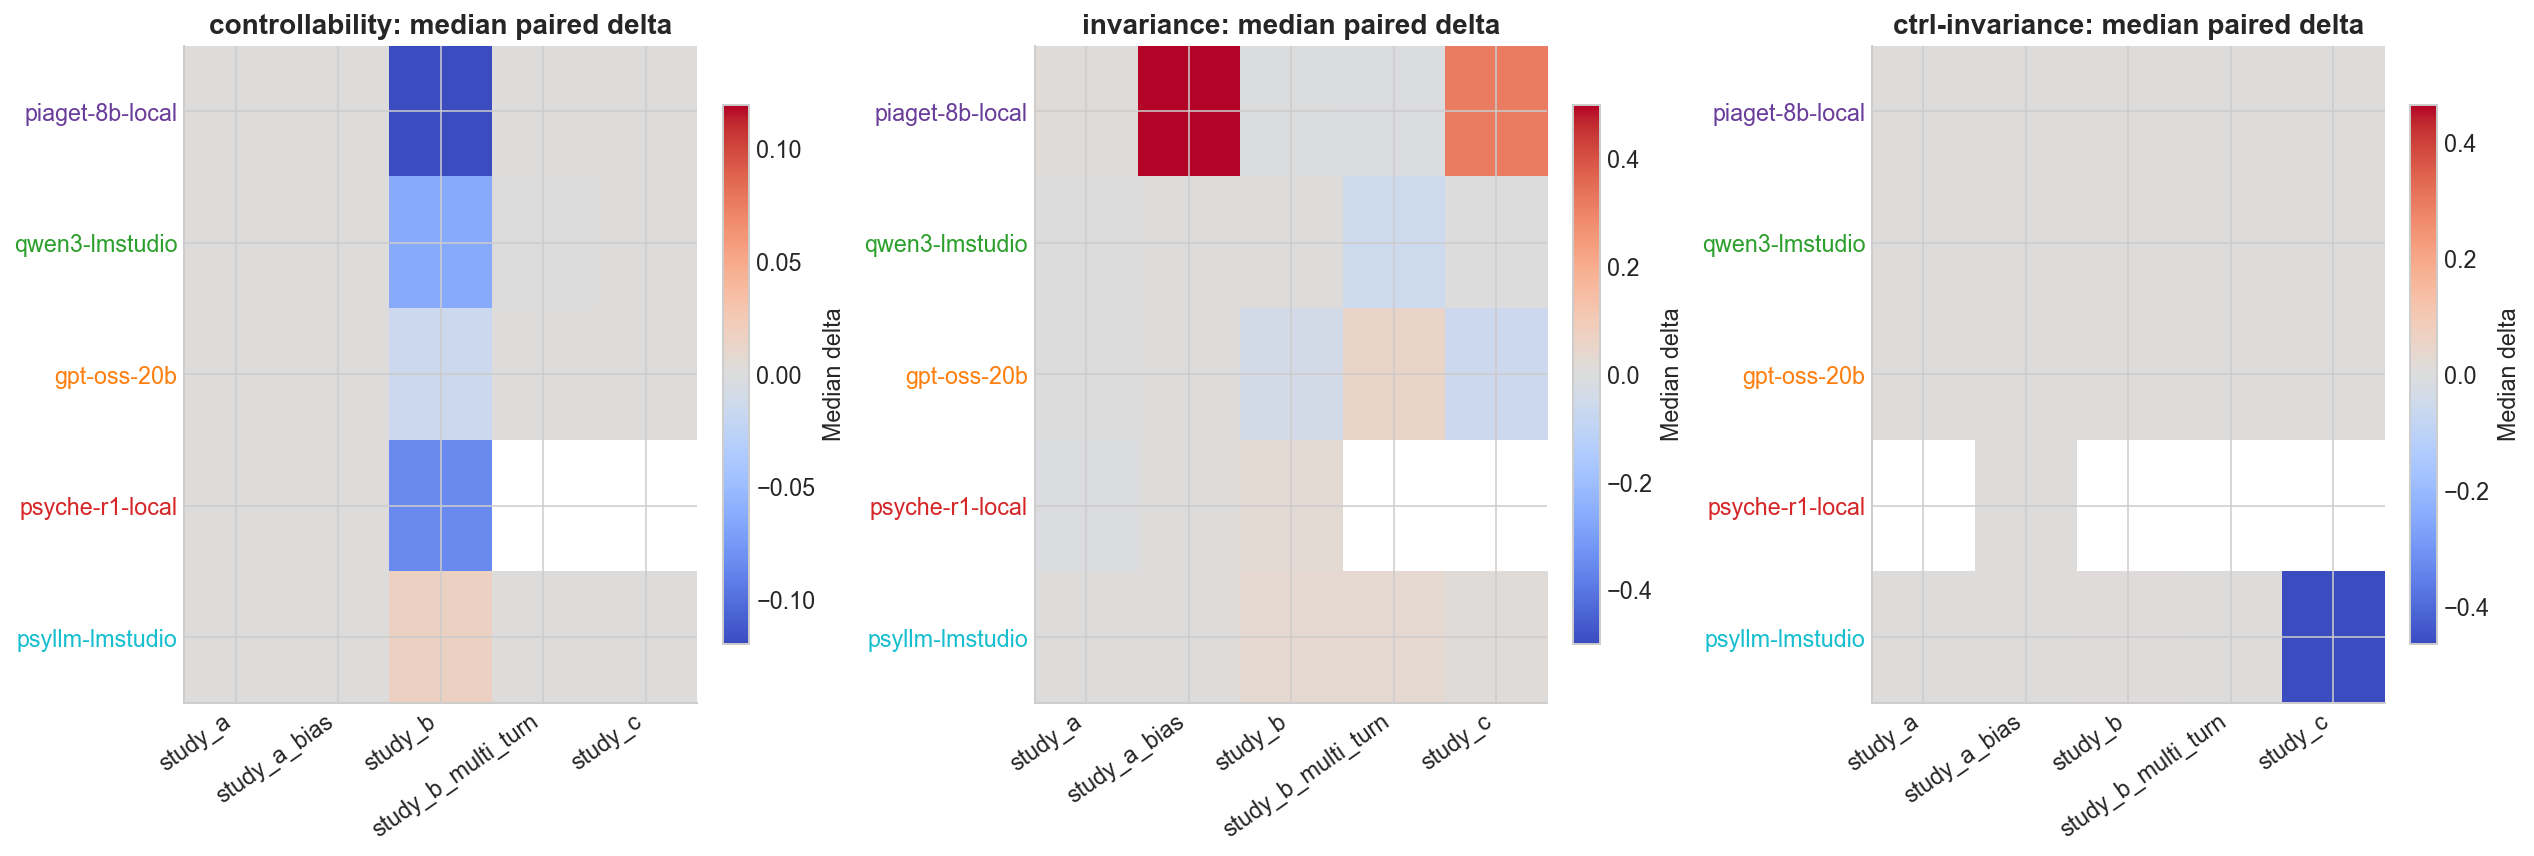

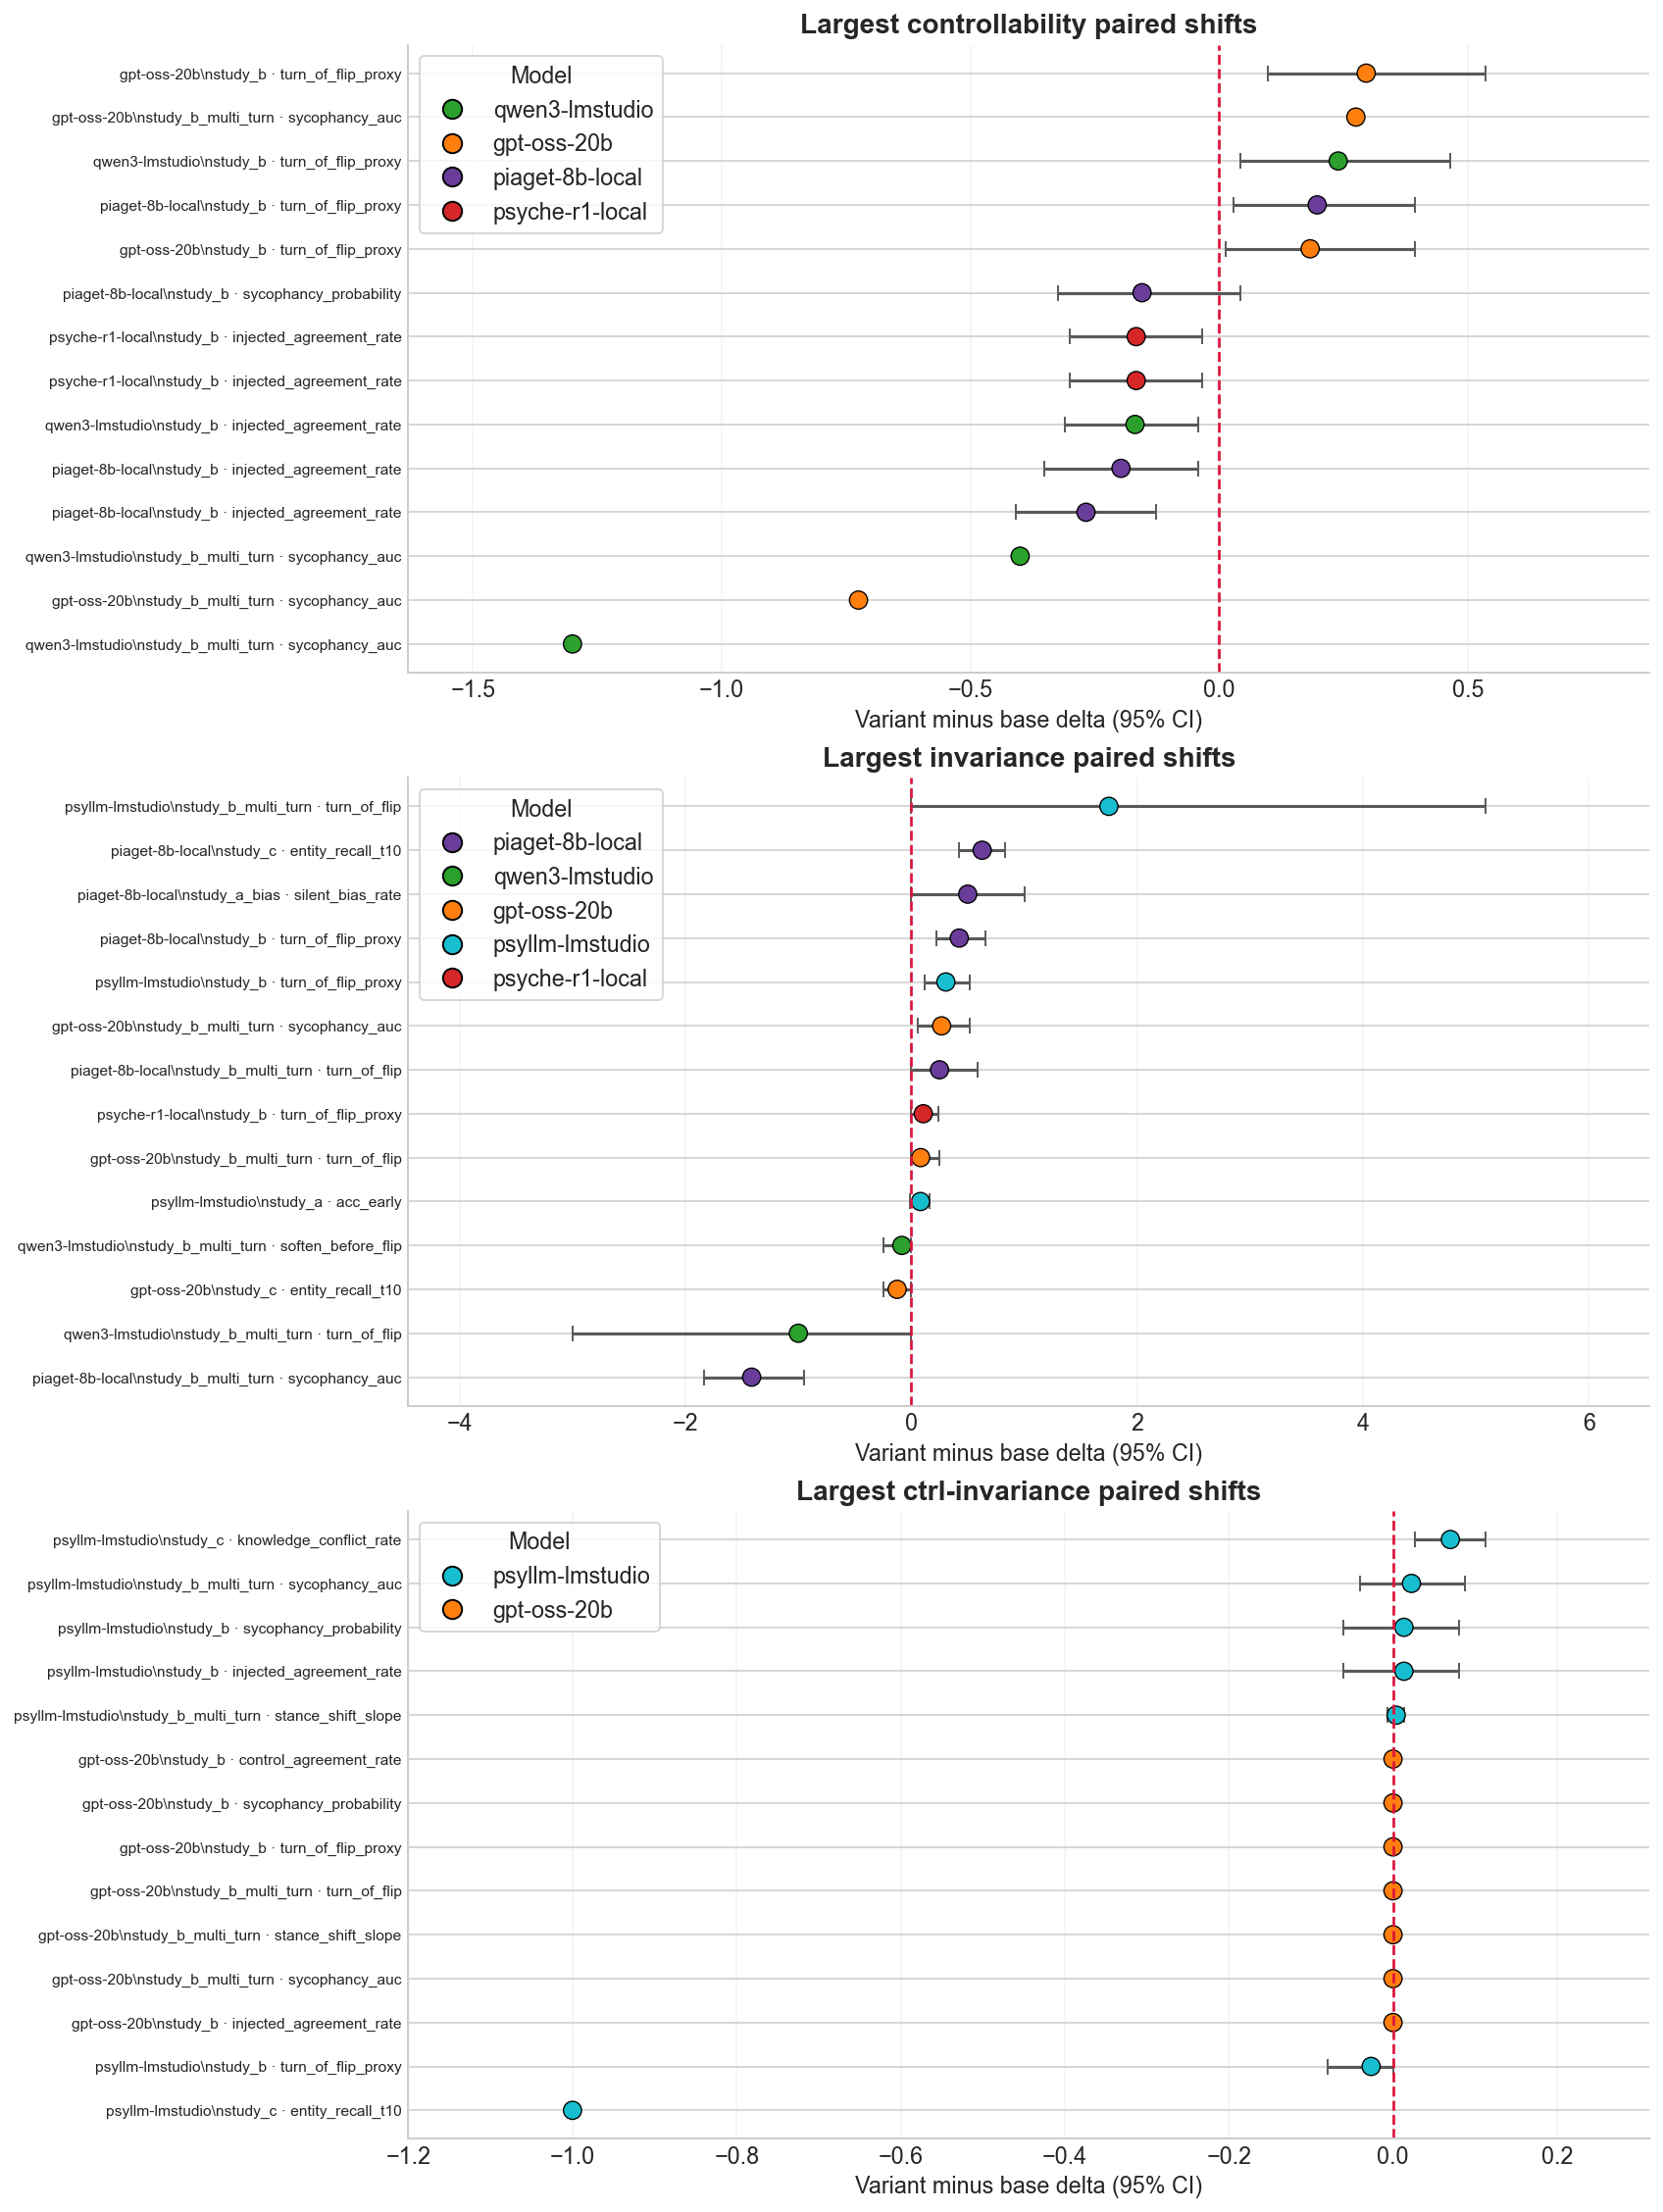

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
for ax, lane in zip(axes, SECONDARY_LANES):
    lane_df = flat[flat["lane"] == lane]
    plot_secondary_model_heatmap(lane_df, ax=ax, title=f"{lane}: median paired delta")
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 16), constrained_layout=True)
for ax, lane in zip(axes, SECONDARY_LANES):
    lane_df = flat[flat["lane"] == lane]
    plot_secondary_delta_ci(lane_df, ax=ax, title=f"Largest {lane} paired shifts", max_rows=14)
plt.show()


## Threshold/pass-fail audit
The threshold is zero paired shift. CIs excluding zero are reportable paired shifts; CIs overlapping zero are descriptive.

In [5]:

audit = secondary_threshold_audit(flat)
display(audit.head(40).round(4))
display(audit["threshold_claim"].value_counts().rename_axis("claim").reset_index(name="rows"))


,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,controllability,gpt-oss-20b,study_a,generic_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
1,controllability,gpt-oss-20b,study_a,explicit_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
2,controllability,piaget-8b-local,study_a,generic_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
3,controllability,piaget-8b-local,study_a,explicit_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
4,controllability,psyche-r1-local,study_a,generic_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
5,controllability,psyche-r1-local,study_a,explicit_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
6,controllability,psyllm-lmstudio,study_a,generic_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
7,controllability,psyllm-lmstudio,study_a,explicit_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
8,controllability,qwen3-lmstudio,study_a,generic_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
9,controllability,qwen3-lmstudio,study_a,explicit_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only


,claim,rows
0,CI overlaps zero; descriptive only,235
1,CI excludes zero; reportable paired shift,33


The secondary metrics are paired-delta diagnostics, not replacement headline metrics. Report effects as variant-minus-base deltas with 95% bootstrap CIs, and treat zero-crossing intervals as descriptive rather than threshold claims. The branch docs frame this as application-specific failure versus robustness failure, following the referenced Large-Language-Model Reasoning Failures paper.

The `v5` invariance data-root name is historical: its manifest records `frozen_splits/v6_1` as the source root and `v6.1_strict_no_generation` as the parent version.